# 1. feature 별 통계 분포 확인 코드

✅ 데이터를 성공적으로 로드했습니다. (총 15,833행)

📊 [주요 지표 기술 통계량]
                     mean        std     min     25%     50%     75%     max
avg_corr         0.824025   0.149438   0.025   0.791   0.871   0.914    1.00
critical_value  12.298490  13.903241   0.000   0.000   7.000  21.000   73.00
daily_peak      19.904187  15.572800   0.000   7.000  16.000  30.000   85.00
peak_ratio      67.881138  16.299043  14.310  56.940  66.940  79.580  100.00
peak_std         2.406699   3.026287   0.000   0.820   1.460   2.480   29.01


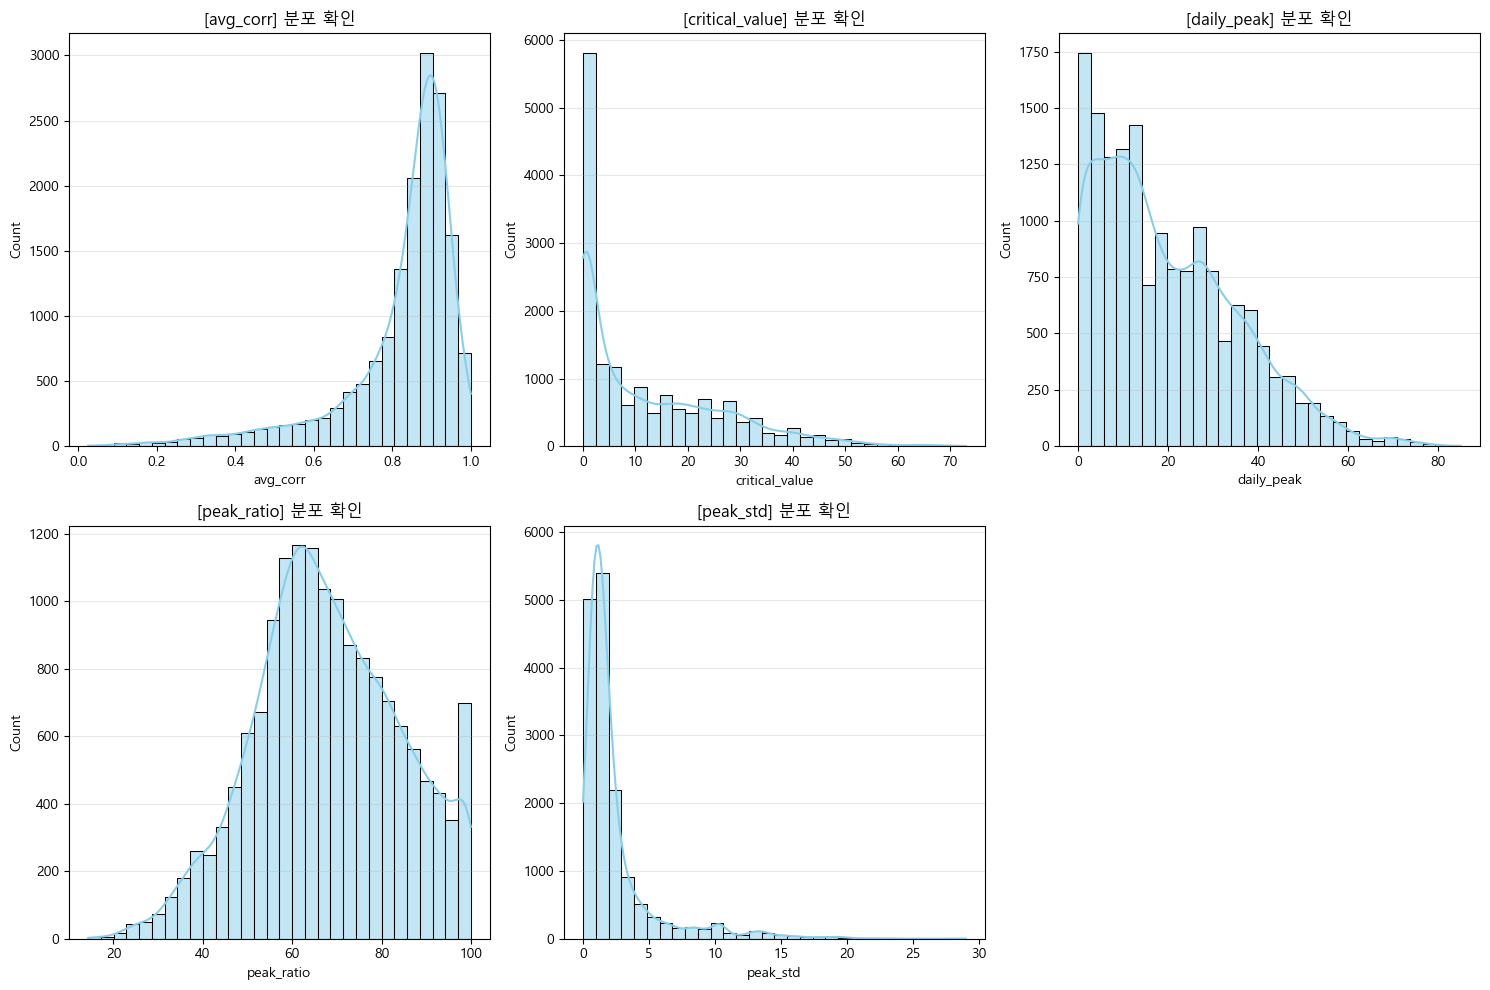

In [ ]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import os

# 1. 파일 경로 확인 (방금 생성한 CSV 파일을 불러옵니다)
BASE_DIR = Path(os.getcwd()).parent
PROCESSED_DIR = BASE_DIR / "01_data" / "02_processed"
SAVE_PATH = PROCESSED_DIR / "02_sensor_daily_features.csv"

# 2. 데이터 로드 (변수명을 daily_features로 확실히 지정)
if os.path.exists(SAVE_PATH):
    daily_features = pd.read_csv(SAVE_PATH)
    print(f"✅ 데이터를 성공적으로 로드했습니다. (총 {len(daily_features):,}행)")
else:
    print("❌ 파일을 찾을 수 없습니다. 경로를 확인해주세요.")

# 3. 분포 확인 함수 정의
def check_distribution(df):
    # 한글 폰트 설정 (Windows 기준)
    plt.rcParams['font.family'] = 'Malgun Gothic'
    plt.rcParams['axes.unicode_minus'] = False
    
    # 분석할 핵심 지표들
    cols = ['avg_corr', 'critical_value', 'daily_peak', 'peak_ratio', 'peak_std']
    
    print("\n📊 [주요 지표 기술 통계량]")
    # 주요 통계치 요약 (평균, 표준편차, 4분위수 등)
    stats = df[cols].describe().T[['mean', 'std', 'min', '25%', '50%', '75%', 'max']]
    print(stats)
    
    # 시각화
    plt.figure(figsize=(15, 10))
    for i, col in enumerate(cols, 1):
        plt.subplot(2, 3, i)
        sns.histplot(df[col], kde=True, color='skyblue', bins=30)
        plt.title(f'[{col}] 분포 확인')
        plt.grid(axis='y', alpha=0.3)
        
    plt.tight_layout()
    plt.show()

# 4. 함수 실행
if 'daily_features' in locals():
    check_distribution(daily_features)



In [10]:
# 1. 각 지표별 75% (Q3) 임계치 계산
q3_corr = daily_features['avg_corr'].quantile(0.75)
q3_peak = daily_features['daily_peak'].quantile(0.75)
q3_ratio = daily_features['peak_ratio'].quantile(0.75)

# 2. 개별 조건 만족 개수 확인
cond_corr = daily_features['avg_corr'] >= q3_corr
cond_peak = daily_features['daily_peak'] >= q3_peak
cond_ratio = daily_features['peak_ratio'] >= q3_ratio

# 3. 교집합(AND) 조건 만족 개수 확인
total_rows = len(daily_features)
danger_rows = daily_features[cond_corr & cond_peak & cond_ratio]

print(f"📊 [교집합 분석 결과]")
print(f"전체 데이터 수: {total_rows:,}개")
print(f"세 조건 동시 만족(위험군): {len(danger_rows):,}개")
print(f"전체 대비 비율: {(len(danger_rows)/total_rows)*100:.2f}%")


📊 [교집합 분석 결과]
전체 데이터 수: 15,833개
세 조건 동시 만족(위험군): 985개
전체 대비 비율: 6.22%


In [11]:
# Q3 기준값 정의 (아까 계산한 값들)
q3_corr = daily_features['avg_corr'].quantile(0.75)
q3_peak = daily_features['daily_peak'].quantile(0.75)
q3_ratio = daily_features['peak_ratio'].quantile(0.75)

# 중앙값(Q2) 기준값 정의 (주의 등급용)
med_corr = daily_features['avg_corr'].median()
med_peak = daily_features['daily_peak'].median()
med_ratio = daily_features['peak_ratio'].median()

def final_labeling(row):
    # [위험 2] : 3대 지표 모두 상위 25% (우리가 확인한 6.22%)
    if (row['avg_corr'] >= q3_corr) and (row['daily_peak'] >= q3_peak) and (row['peak_ratio'] >= q3_ratio):
        return 2
    # [주의 1] : 위험은 아니지만, 모든 지표가 평균(중앙값) 이상인 경우
    elif (row['avg_corr'] >= med_corr) and (row['daily_peak'] >= med_peak) and (row['peak_ratio'] >= med_ratio):
        return 1
    # [정상 0] : 그 외 (소리가 작거나 불안정함)
    else:
        return 0

daily_features['label'] = daily_features.apply(final_labeling, axis=1)

print("✅ 최종 라벨링 분포 확인:")
print(daily_features['label'].value_counts(normalize=True).sort_index() * 100)


✅ 최종 라벨링 분포 확인:
label
0    80.717489
1    13.061328
2     6.221184
Name: proportion, dtype: float64
